#Initial Setup

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [3]:
import os
import shutil
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#VIDEO PROCESSING

In [5]:
!yolo task=detect mode=predict conf=0.25 save=True model='best.pt' source='carLicence4.mp4'

Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

video 1/1 (frame 1/631) /content/carLicence4.mp4: 416x640 1 license_plate, 56.5ms
video 1/1 (frame 2/631) /content/carLicence4.mp4: 416x640 1 license_plate, 9.3ms
video 1/1 (frame 3/631) /content/carLicence4.mp4: 416x640 1 license_plate, 8.7ms
video 1/1 (frame 4/631) /content/carLicence4.mp4: 416x640 1 license_plate, 8.5ms
video 1/1 (frame 5/631) /content/carLicence4.mp4: 416x640 1 license_plate, 9.4ms
video 1/1 (frame 6/631) /content/carLicence4.mp4: 416x640 1 license_plate, 8.4ms
video 1/1 (frame 7/631) /content/carLicence4.mp4: 416x640 1 license_plate, 9.3ms
video 1/1 (frame 8/631) /content/carLicence4.mp4: 416x640 1 license_plate, 8.3ms
video 1/1 (frame 9/631) /content/carLicence4.mp4: 416x640 2 license_plates, 9.0ms
video 1/1 (frame 10/631) /content/carLicence4.mp4: 416x640 2 license_plates, 8.6ms
video 1/1 (frame 11

In [26]:
import cv2
import torch
import easyocr
from ultralytics import YOLO  # YOLOv11
import time

# Load YOLOv11 model
model = YOLO("/content/best.pt")  # Replace with your trained YOLOv11 model

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Load video file
video_path = "/content/carLicence4.mp4"  # Replace with your video path
cap = cv2.VideoCapture(video_path)

# Define output video writer
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output_video.avi', fourcc, 20.0,
                      (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
                       int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # YOLOv11 Detection
    results = model(frame)

    for result in results:
        boxes = result.boxes  # Detected bounding boxes

        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coords

            # Crop license plate
            license_plate = frame[y1:y2, x1:x2]

            # Convert to grayscale
            gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

            # OCR detection
            text_results = reader.readtext(gray_plate)
            extracted_text = " ".join([text[1] for text in text_results])

            # Draw bounding box and text
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, extracted_text, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Show the frame (optional in Colab)
    # cv2_imshow(frame)  # Use only in Colab
    out.write(frame)  # Write frame to output video

cap.release()
out.release()




0: 416x640 1 license_plate, 13.0ms
Speed: 2.7ms preprocess, 13.0ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.4ms
Speed: 3.6ms preprocess, 9.4ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.5ms
Speed: 3.1ms preprocess, 9.5ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.0ms
Speed: 3.3ms preprocess, 9.0ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 11.4ms
Speed: 3.1ms preprocess, 11.4ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 11.7ms
Speed: 3.2ms preprocess, 11.7ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 11.8ms
Speed: 3.3ms preprocess, 11.8ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 10.0ms
Speed: 3.0ms preprocess, 10.0ms inferen

In [42]:
import cv2
import torch
import easyocr
import pandas as pd
from ultralytics import YOLO
import re

# Load YOLOv11 model (trained on license plates)
model = YOLO("/content/best.pt")  # Update this path to your YOLOv11 weights

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Open the video file
video_path = "/content/carLicence4.mp4"  # Update with your video path
cap = cv2.VideoCapture(video_path)

# List to store license plates matching the format
detected_plates = []

# Define the regex pattern
plate_pattern = re.compile(r'^[A-Z][0-9]{3}[A-Z]{2}$')

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Run YOLOv11 detection
    results = model(frame)

    for result in results:
        boxes = result.boxes

        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Crop the detected license plate
            license_plate = frame[y1:y2, x1:x2]

            # Convert to grayscale for OCR
            gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

            # OCR with EasyOCR
            text_results = reader.readtext(gray_plate)

            # Extract and clean text
            for (_, text, _) in text_results:
                cleaned_text = re.sub(r'[^A-Z0-9]', '', text.upper())  # Clean text
                if plate_pattern.fullmatch(cleaned_text) and cleaned_text not in detected_plates:
                    detected_plates.append(cleaned_text)
                    print(f"Frame {frame_count}: Valid Plate -> {cleaned_text}")

cap.release()

# Save to Excel
df = pd.DataFrame(detected_plates, columns=["License Plate"])
excel_path = "/content/detected_license_plates.xlsx"
df.to_excel(excel_path, index=False)
print(f"\n✅ License plates matching pattern saved to: {excel_path}")



0: 416x640 1 license_plate, 12.8ms
Speed: 2.5ms preprocess, 12.8ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 10.2ms
Speed: 3.1ms preprocess, 10.2ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.5ms
Speed: 3.2ms preprocess, 9.5ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.2ms
Speed: 3.0ms preprocess, 9.2ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.8ms
Speed: 3.2ms preprocess, 9.8ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.2ms
Speed: 3.0ms preprocess, 9.2ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.5ms
Speed: 3.1ms preprocess, 9.5ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 license_plate, 9.4ms
Speed: 2.5ms preprocess, 9.4ms inference, 1.

In [44]:
import pandas as pd

# Path to the Excel file (update if needed)
excel_path = "/content/detected_license_plates_video.xlsx"

# Load the Excel file into a DataFrame
df = pd.read_excel(excel_path)

# Print the contents
print("License Plate Numbers from Excel:")
for index, row in df.iterrows():
    print(row['License Plate'])  # Replace 'License Plate' if your column name differs


License Plate Numbers from Excel:
R183JF
N894JV
L656XH
L656XR
H644LX
K884RS
66HH07
L605HZ
R197GB


#EXTRACTING TEXT AND STORING IN EXCEL SHEET

In [7]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 20.9 MB/s eta 0:00:00



0: 480x640 1 license_plate, 20.3ms
Speed: 3.1ms preprocess, 20.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
License Plate Text: MH43CC1745


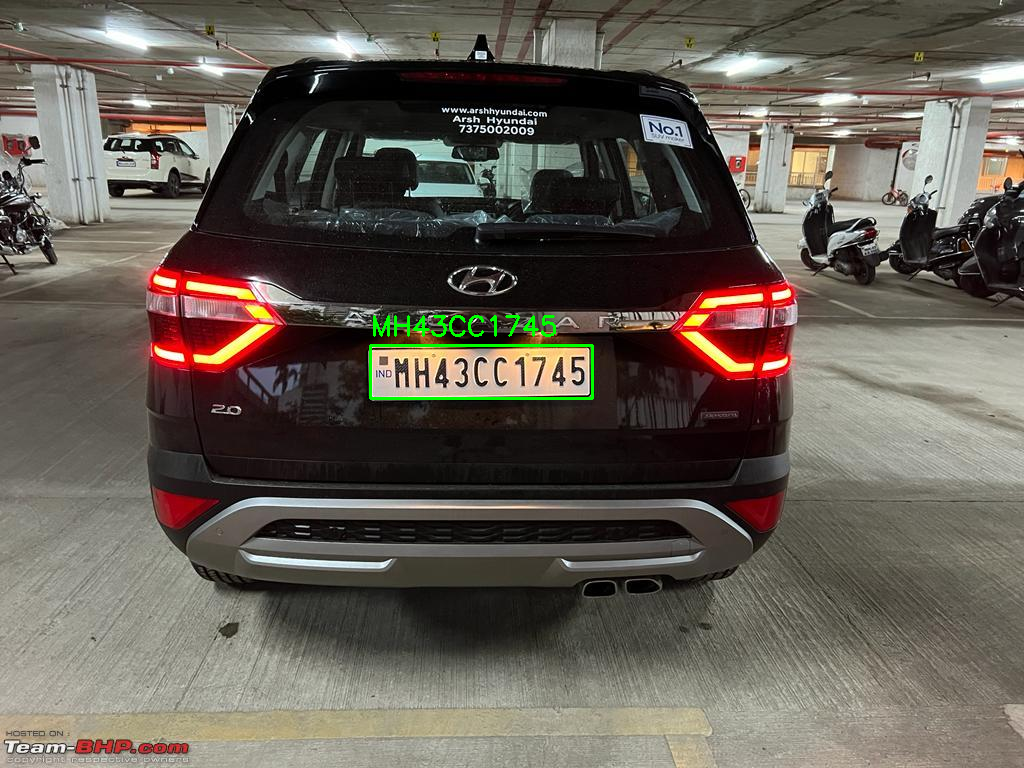

True

In [19]:
import cv2
import torch
import easyocr
from ultralytics import YOLO  # YOLOv11 model
from google.colab.patches import cv2_imshow
import re
# Load YOLOv11 model
model = YOLO("/content/best.pt")  # Make sure best.pt is your trained license plate detector

# Load the uploaded image
image_path = "/content/hyundai.jpeg"  # <- this is your uploaded image path
image = cv2.imread(image_path)

# Run YOLO detection
results = model(image)

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Process each detected object
for result in results:
    boxes = result.boxes  # Get bounding boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coordinates

        # Crop the detected license plate
        license_plate = image[y1:y2, x1:x2]

        # Convert to grayscale for OCR
        gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

        # Run OCR
        text_results = reader.readtext(gray_plate)

        # Extract and print OCR text
        raw_text = " ".join([text[1] for text in text_results])
        extracted_text = re.sub(r'[^A-Z0-9]', '', raw_text.upper())
        print(f"License Plate Text: {extracted_text}")

        # Draw results on image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, extracted_text, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Show final output
cv2_imshow(image)
cv2.imwrite("/content/output_plate.jpg", image)



In [20]:
!pip install openpyxl


0: 480x640 1 license_plate, 13.0ms
Speed: 3.0ms preprocess, 13.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
License Plate Text: MH43CC1745


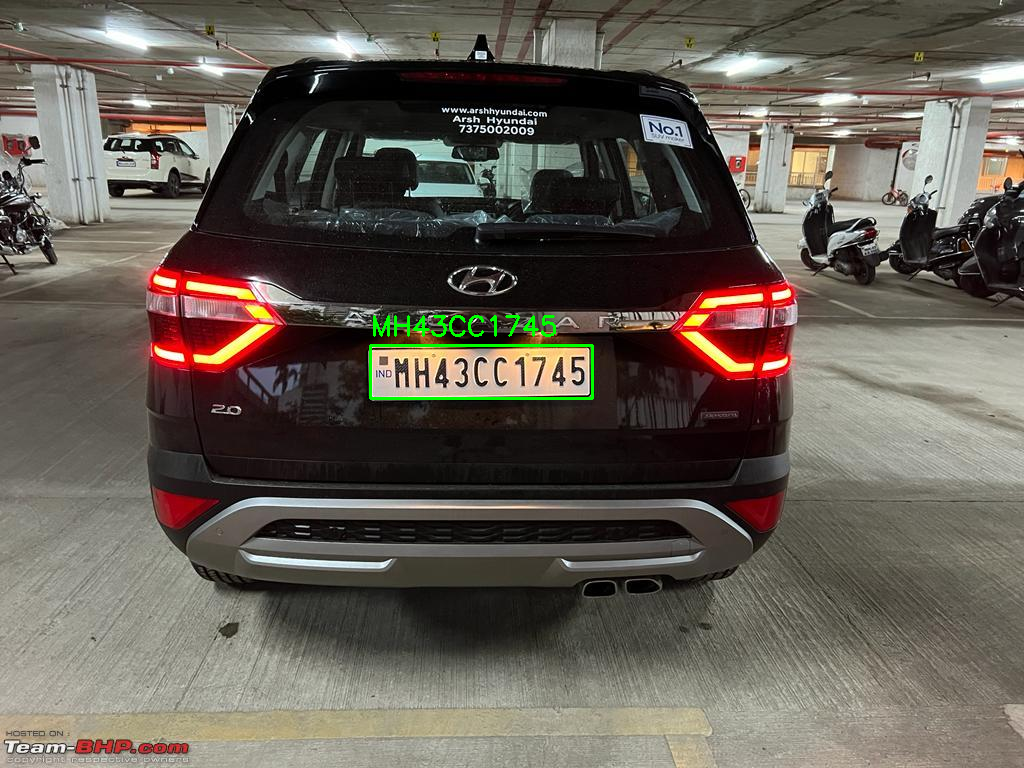

True

In [23]:
import cv2
import torch
import easyocr
import pandas as pd
from openpyxl import load_workbook
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
# Load YOLOv11 model
model = YOLO("/content/best.pt")  # Replace with your model path

# Load the image
image_path = "/content/hyundai.jpeg"
image = cv2.imread(image_path)

# Run YOLO detection
results = model(image)

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Excel file to store license plate numbers
excel_file = "/content/LICENSEPLATE_GUESTS_DATABASE.xlsx"

# List to store extracted license plate texts
plate_numbers = []

# Process each detected object
for result in results:
    boxes = result.boxes  # Get bounding boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get coordinates

        # Crop the detected license plate
        license_plate = image[y1:y2, x1:x2]

        # Convert to grayscale (optional for better OCR accuracy)
        gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

        # Run OCR on the cropped plate
        text_results = reader.readtext(gray_plate)

        # Extract and print OCR text
        raw_text = " ".join([text[1] for text in text_results])
        extractedtext = re.sub(r'[^A-Z0-9]', '', raw_text.upper())
        print(f"License Plate Text: {extractedtext}")

        # Save extracted text to list
        plate_numbers.append([extracted_text])

        # Draw bounding box and text on image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, extractedtext, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Save or display the output image
cv2_imshow(image)
cv2.imwrite("output.jpg", image)

In [24]:
# Save to Excel
df = pd.DataFrame(plate_numbers, columns=["License Plate"])

# Check if file exists and update it
try:
    existing_df = pd.read_excel(excel_file)
    df = pd.concat([existing_df, df], ignore_index=True)  # Append new data
except FileNotFoundError:
    pass  # If file doesn't exist, create a new one

df.to_excel(excel_file, index=False)  # Save to Excel
print(f"License plate numbers saved to {excel_file}")

License plate numbers saved to /content/LICENSEPLATE_GUESTS_DATABASE.xlsx


In [25]:
import pandas as pd

# Load the Excel file
file_path = "/content/LICENSEPLATE_GUESTS_DATABASE.xlsx"
df = pd.read_excel(file_path)

# Display all columns (optional, to help you find which one holds license plates)
print("Columns in the file:", df.columns)

# Assuming the column is named something like 'License Plate' or similar
# Replace 'License Plate' with the actual column name after inspecting columns
license_plate_column = 'License Plate'  # <-- Update this if needed

# Print all license plate numbers
print("License Plate Numbers:")
for plate in df[license_plate_column].dropna():
    print(str(plate).strip().upper())


Columns in the file: Index(['License Plate'], dtype='object')
License Plate Numbers:
KA 02MP 9657
TN 21 BZ 0768
RJ 27 TC 0530
TN 21 AT 0492
MH 46 X 9996
HR 26 CK 8571
KL 63 C 8800
TN 10 AB 1234
KA 05 CD 5678
MH 12 EF 9012
DL 04 GH 3456
AP 16 IJ 7890
GJ 01 KL 1122
RJ 14 MN 3344
WB 06 OP 5566
KL 07 QR 7788
PB 10 ST 9900
HR 26 UV 1234
MP 09 WX 5678
CG 04 YZ 9012
BR 01 AA 3456
OD 02 BB 7890
UK 07 CC 1122
AS 01 DD 3344
HP 63 EE 5566
JH 05 FF 7788
GA 03 GG 9900
TS 09 1234
AR 01 5678
MH43CC1745


#Authorization


0: 640x640 1 license_plate, 18.3ms
Speed: 6.3ms preprocess, 18.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Detected License Plate: MH 20EJ 0364
❌ License Plate MH 20EJ 0364 is NOT in the database.


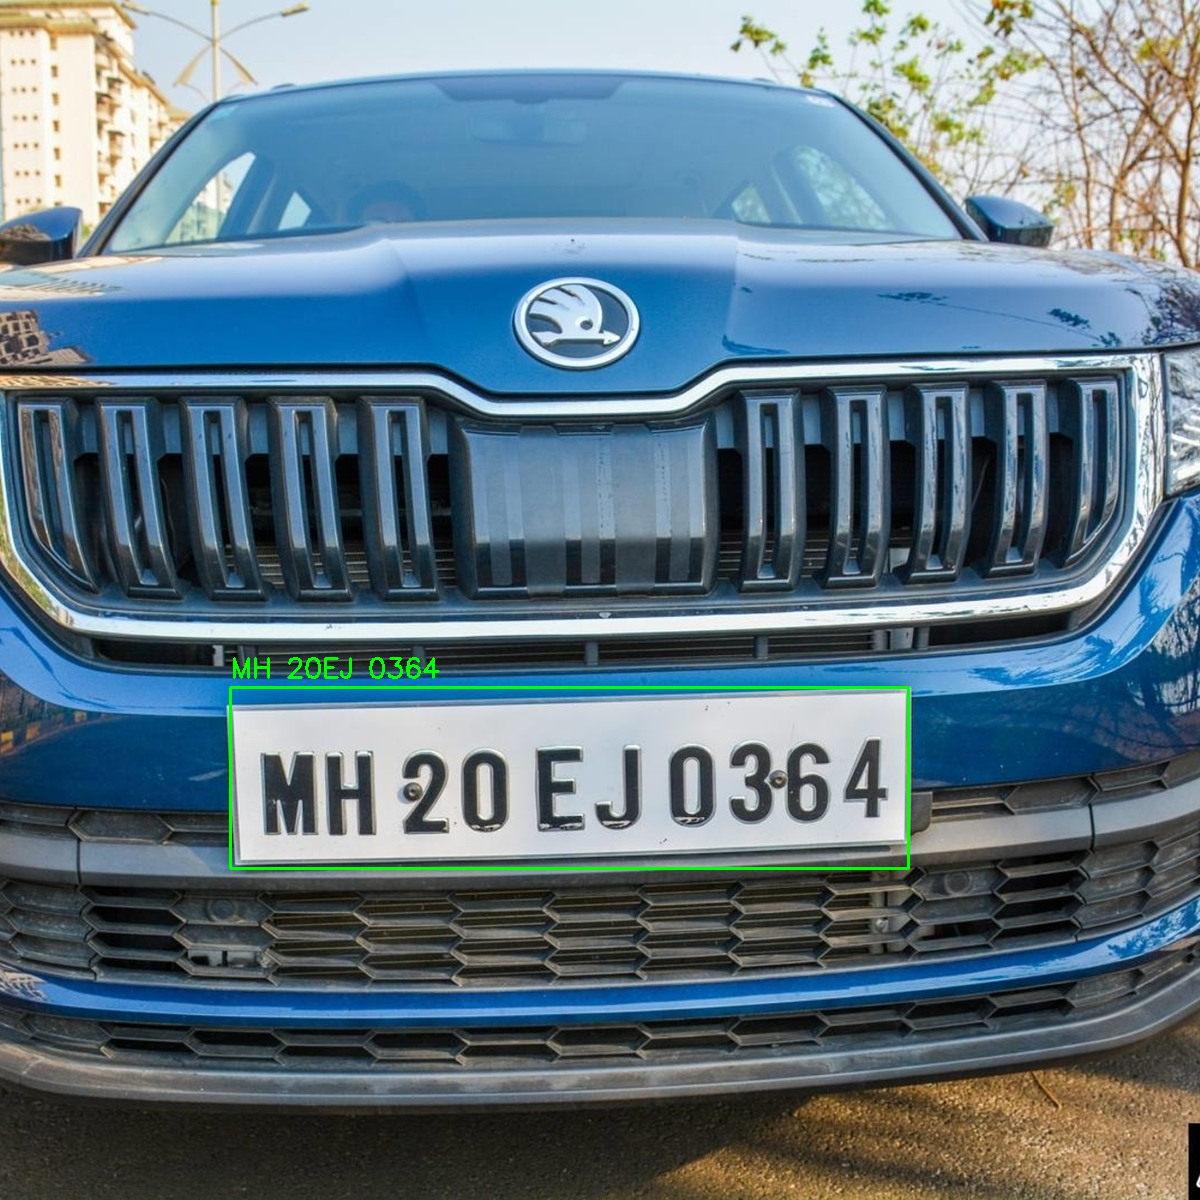

True

In [29]:
import cv2
import torch
import easyocr
import pandas as pd
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
# Load YOLOv11 model
model = YOLO("/content/best.pt")  # Replace with your trained YOLOv11 model path

# Load the image
image_path = "/content/dataset-card.jpg"  # Replace with your test image
image = cv2.imread(image_path)

# Run YOLO detection
results = model(image)

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Path to the Excel file
excel_file = "/content/LICENSEPLATE_GUESTS_DATABASE.xlsx"

# Read the existing Excel file
try:
    existing_df = pd.read_excel(excel_file)
    existing_plates = existing_df["License Plate"].astype(str).tolist()  # Convert to list
except FileNotFoundError:
    existing_plates = []  # If file doesn't exist, assume empty list

# Process each detected license plate
found_plates = []

for result in results:
    boxes = result.boxes  # Get bounding boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get coordinates

        # Crop the detected license plate
        license_plate = image[y1:y2, x1:x2]

        # Convert to grayscale (optional for better OCR accuracy)
        gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

        # Run OCR on the cropped plate
        text_results = reader.readtext(gray_plate)

        # Extract text from OCR result
        extracted_text = " ".join([text[1] for text in text_results])
        extracted_text = extracted_text.strip().upper()  # Normalize text

        print(f"Detected License Plate: {extracted_text}")

        # Check if the detected license plate is in the Excel file
        if extracted_text in existing_plates:
            print(f"✅ License Plate {extracted_text} is in the database.")
            found_plates.append(extracted_text)
        else:
            print(f"❌ License Plate {extracted_text} is NOT in the database.")

        # Draw bounding box and text on image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, extracted_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Save or display the output image
cv2_imshow(image)
cv2.imwrite("output.jpg", image)

